# Unemployment Rate Analysis in India

The data file reports unemployment estimates recorded across different regions in India. This is an exploratory analysis rather than a prediction task. The goal is to understand how the unemployment rate evolved over time, whether the Covid-19 period had a visible impact, and whether seasonal or regional patterns emerge. The analysis follows a progressive approach, from cleaning the data to drawing insights that could inform economic or social policies.

## 1. Imports

This consists of importing the packages needed for the whole program.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.precision", 2)

## 2. Loading the data

Loading the data file makes it possible to explore it and prepare the rest of the analysis.

In [ ]:
data = pd.read_csv("Unemployment_in_India.csv")
data.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,1.20e+07,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,1.18e+07,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,1.21e+07,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,1.23e+07,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,1.23e+07,44.68,Rural


**Interpretation :** Each row corresponds to a given region and month, with the estimated unemployment rate, the number of people employed and the labour participation rate, for a rural or urban area. The column names start with a space, such as `" Date"`, which is a sign that some cleaning will be needed.

## 3. First look at the dataset

A first review checks the size of the file, the column names, the column types and the amount of missing values, before going further in the analysis.

In [ ]:
print("Total number of rows:", data.shape[0])
print("Total number of columns:", data.shape[1])
print("Column names:", data.columns.tolist())
print()
data.info()

Total number of rows: 768
Total number of columns: 7
Column names: ['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


**Interpretation :** The file has 768 rows and 7 columns. Only 740 out of 768 rows have non-null values in every column, as shown in the next cell, and the numeric columns are correctly typed as `float64`. The column names confirm the presence of stray spaces at the start of the strings.

In [ ]:
data.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

**Interpretation :** The file contains 768 rows in total, of which exactly 28 have missing values across all columns. These 28 empty rows fall into two blocks: 14 rows act as a separator between the "Rural" block and the "Urban" block in the middle of the file, and 14 others are empty rows at the end of the file. In addition, the column names contain extra spaces, such as `" Date"` and `" Frequency"`, which would prevent the columns from being accessed correctly if left uncleaned. Both issues therefore need to be fixed before any analysis.

## 4. Cleaning the data

This step removes the empty rows, cleans the column names and values, converts the date column to an actual date, and renames the numeric columns to shorter labels.

In [ ]:
data.columns = [column.strip() for column in data.columns]
data = data.dropna()

for column in ["Region", "Frequency", "Area"]:
    data[column] = data[column].str.strip()

data["Date"] = pd.to_datetime(data["Date"].str.strip(), format="%d-%m-%Y")

data = data.rename(columns={
    "Estimated Unemployment Rate (%)": "Unemployment Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour Participation Rate",
})

data.head()

,Region,Date,Frequency,Unemployment Rate,Employed,Labour Participation Rate,Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,1.20e+07,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,1.18e+07,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,1.21e+07,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,1.23e+07,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,1.23e+07,44.68,Rural


In [ ]:
print("Remaining rows after cleaning:", data.shape[0])
print("Period covered:", data["Date"].min().date(), "to", data["Date"].max().date())
print("Number of regions:", data["Region"].nunique())

Remaining rows after cleaning: 740
Period covered: 2019-05-31 to 2020-06-30
Number of regions: 28


**Interpretation :** After cleaning, 740 usable rows remain, since 28 empty rows were removed from the original 768. The data covers the period from May 31, 2019 to June 30, 2020, a little over 13 months, spread across 28 regions of India. The dataset is now clean: dates in datetime format, column names without spaces, and columns renamed for clarity.

## 5. Descriptive statistics

These statistics give a first idea of the distribution of the unemployment rate, the number of people employed and the labour participation rate.

In [ ]:
data[["Unemployment Rate", "Employed", "Labour Participation Rate"]].describe()

,Unemployment Rate,Employed,Labour Participation Rate
count,740.00,7.40e+02,740.00
mean,11.79,7.20e+06,42.63
std,10.72,8.09e+06,8.11
min,0.00,4.94e+04,13.33
25%,4.66,1.19e+06,38.06
50%,8.35,4.74e+06,41.16
75%,15.89,1.13e+07,45.51
max,76.74,4.58e+07,72.57


**Interpretation :** The average unemployment rate over the whole period is 11.79%, with a high standard deviation of 10.72 points, reflecting strong dispersion. Values range from a minimum of 0% to a maximum of 76.74%, a considerable gap compared to the median of 8.35% and the 3rd quartile of 15.89%. Such a maximum, far removed from the rest of the distribution, therefore confirms the presence of a sharp, localized shock rather than a stable general trend.

## 6. Unemployment rate over time

This step plots the evolution of the average unemployment rate over time, in order to spot the overall trend.

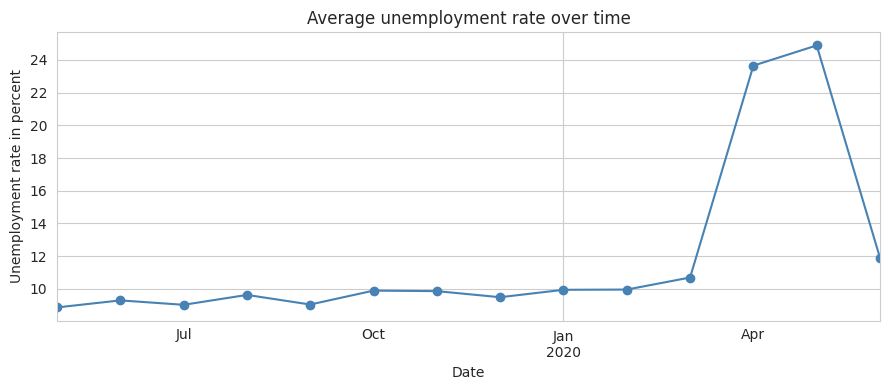

In [ ]:
trend = data.groupby("Date")["Unemployment Rate"].mean().sort_index()

plt.figure(figsize=(9, 4))
trend.plot(marker="o", color="steelblue")
plt.title("Average unemployment rate over time")
plt.xlabel("Date")
plt.ylabel("Unemployment rate in percent")
plt.tight_layout()
plt.show()

**Interpretation :** The average rate stays stable around 9 and 10% between May 2019 and March 2020. It then jumps sharply to 23.64% in April 2020, peaks at 24.88% in May 2020, then falls back to 11.90% in June 2020, still above the pre-crisis level. This surge coincides exactly with the nationwide lockdown declared in India on March 25, 2020 to fight Covid-19.

## 7. Impact of Covid-19

This step compares the average unemployment rate before and during the Covid-19 period, in order to measure its impact directly.

In [ ]:
lockdown_start = pd.Timestamp("2020-03-25")
data["Period"] = np.where(data["Date"] < lockdown_start, "Before Covid-19", "During Covid-19")

covid_comparison = data.groupby("Period")["Unemployment Rate"].mean()
covid_comparison

Period
Before Covid-19     9.51
During Covid-19    17.77
Name: Unemployment Rate, dtype: float64

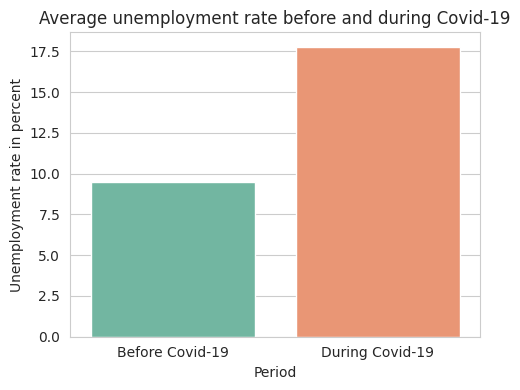

In [ ]:
plt.figure(figsize=(5, 4))
sns.barplot(x=covid_comparison.index, y=covid_comparison.values, order=["Before Covid-19", "During Covid-19"], hue=covid_comparison.index, palette="Set2", legend=False)
plt.title("Average unemployment rate before and during Covid-19")
plt.xlabel("Period")
plt.ylabel("Unemployment rate in percent")
plt.tight_layout()
plt.show()

**Interpretation :** The average unemployment rate rises from 9.51% before the lockdown to 17.77% during the Covid-19 period, an increase of about 1.87 times, thus close to a doubling. This gap statistically confirms the massive impact of the lockdown on employment nationwide.

## 8. Seasonal trends

This step looks at the average unemployment rate by month, in order to check for recurring patterns across the year.

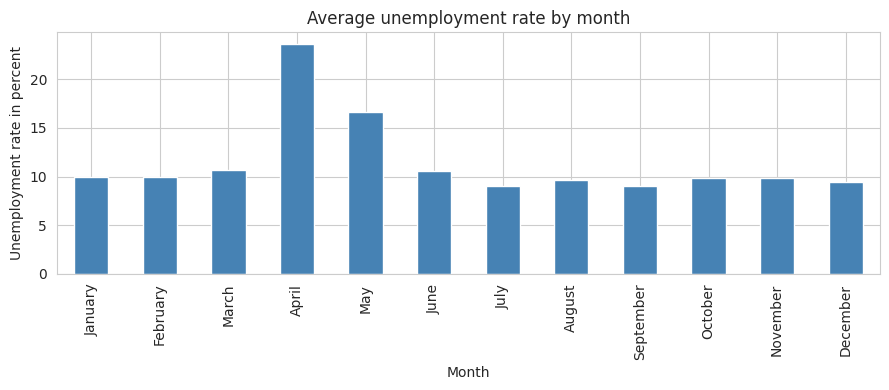

In [ ]:
data["Month"] = data["Date"].dt.month_name()
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_pattern = data.groupby("Month")["Unemployment Rate"].mean().reindex(month_order)

plt.figure(figsize=(9, 4))
monthly_pattern.plot(kind="bar", color="steelblue")
plt.title("Average unemployment rate by month")
plt.xlabel("Month")
plt.ylabel("Unemployment rate in percent")
plt.tight_layout()
plt.show()

**Interpretation :** The month of April stands out very clearly with an average rate of 23.64%, followed by May at 16.65%. All other months fall within a much narrower range, from 9.03% in July to 10.70% in March. Since the dataset only covers a single occurrence of April and May, namely that of 2020 during the lockdown, this monthly peak reflects the Covid-19 shock rather than a recurring seasonality, so several years of data would be needed to settle this question.

## 9. Regional comparison

This step compares the average unemployment rate across regions, in order to identify where the situation is most severe.

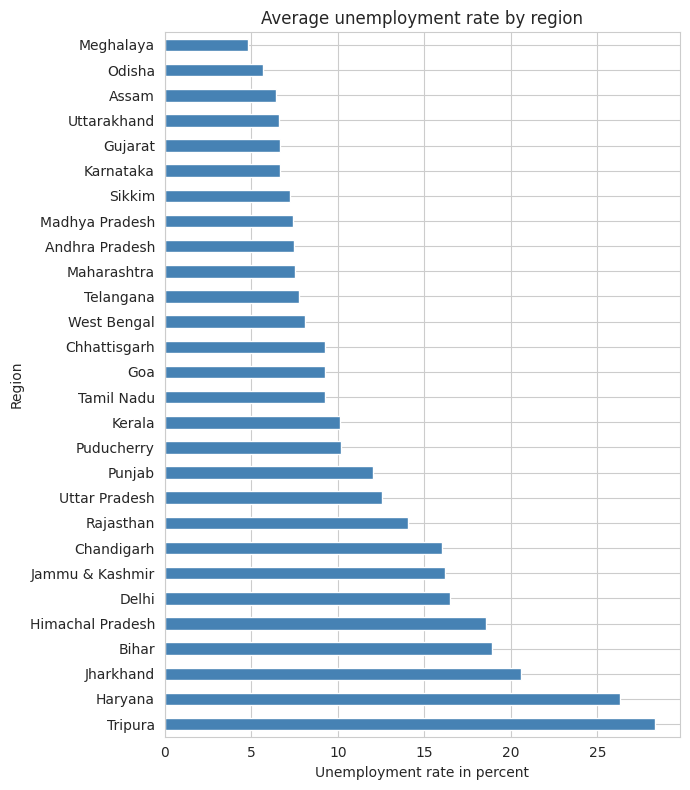

In [ ]:
regional_average = data.groupby("Region")["Unemployment Rate"].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 8))
regional_average.plot(kind="barh", color="steelblue")
plt.title("Average unemployment rate by region")
plt.xlabel("Unemployment rate in percent")
plt.tight_layout()
plt.show()

**Interpretation :** The regional ranking confirms strong disparities: Tripura at 28.35% and Haryana at 26.28% show the highest average rates, followed by Jharkhand at 20.59% and Bihar at 18.92%. Conversely, Meghalaya at 4.80% and Odisha at 5.66% show the lowest rates, followed by Assam and Uttarakhand, both around 6.4% to 6.6%. The gap between the most and least affected region exceeds a factor of five to six, which goes well beyond what the Covid-19 shock alone would explain, and therefore points to lasting structural differences between regions.

## 10. Rural versus urban areas

This step compares the unemployment rate between rural and urban areas, before and during Covid-19, in order to check whether the impact differs by area type.

In [ ]:
area_comparison = data.groupby(["Area", "Period"])["Unemployment Rate"].mean().unstack()
area_comparison

Period,Before Covid-19,During Covid-19
Area,,
Rural,8.09,16.18
Urban,10.84,19.28


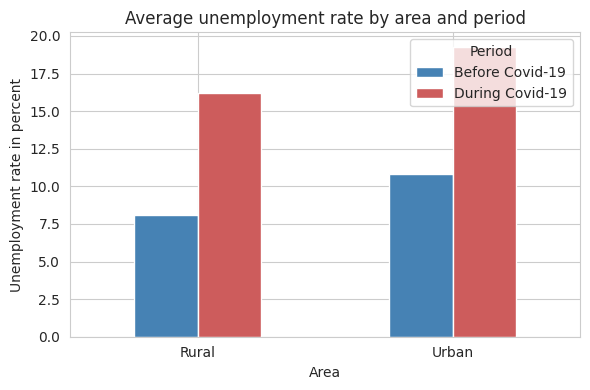

In [ ]:
area_comparison.plot(kind="bar", figsize=(6, 4), color=["steelblue", "indianred"])
plt.title("Average unemployment rate by area and period")
plt.xlabel("Area")
plt.ylabel("Unemployment rate in percent")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation :** The urban rate remains higher than the rural rate both before and during Covid-19, at 10.84% vs 8.09% before and 19.28% vs 16.18% during. Both areas experience a marked increase, but in different proportions: the rural rate rises from 8.09% to 16.18%, thus multiplied by 2, slightly more than the urban rate, which rises from 10.84% to 19.28% and is multiplied by 1.78. The shock therefore affects both types of areas, with a slightly stronger relative impact in rural areas, even though the absolute level remains higher in urban areas.

## 11. Relationship between the indicators

This step measures the correlation between the unemployment rate, the number of people employed and the labour participation rate.

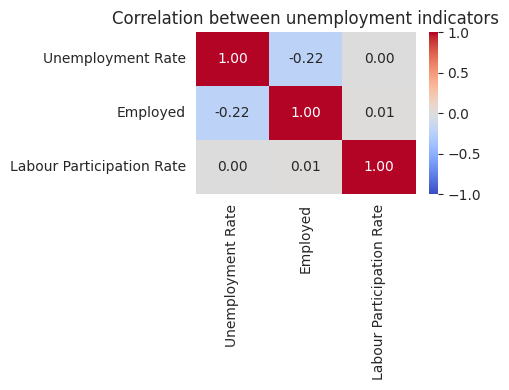

In [ ]:
correlation_matrix = data[["Unemployment Rate", "Employed", "Labour Participation Rate"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation between unemployment indicators")
plt.tight_layout()
plt.show()

**Interpretation :** The correlations are generally weak: the unemployment rate and the number of people employed show a correlation of negative 0.22, that is a slight inverse tendency without a strong link, while the unemployment rate and the labour participation rate are practically independent at a positive 0.003. The number of people employed and the participation rate are also very weakly correlated, at a positive 0.01. This confirms that the surge in unemployment during Covid-19 stems from an external shock, namely the lockdown itself, rather than a structural shift in labour market participation.

## Conclusion

The unemployment rate stayed relatively stable for most of the period covered, then rose sharply around the start of the Covid-19 lockdown, roughly doubling on average before easing back in the following months. The impact was felt in both rural and urban areas, though urban areas started and stayed at a higher level throughout.

Beyond the Covid-19 shock, clear regional disparities appear, with some regions carrying a persistently higher unemployment rate than others regardless of the period. The apparent monthly pattern is largely explained by this same shock rather than by a genuine yearly season, since the data covers only a little over a year.

These findings point to two directions for policy attention, a targeted response for the regions with structurally higher unemployment, and contingency measures ready to absorb sudden shocks of the kind observed during the lockdown. Extending the data over several more years would help confirm whether a true seasonal pattern exists once the Covid-19 period is set aside.